In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Görüntüleme ayarları
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Görsel stili
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Tüm kütüphaneler başarıyla yüklendi.")
print(f"Pandas sürümü: {pd.__version__}")
print(f"Numpy sürümü: {np.__version__}")

✅ Tüm kütüphaneler başarıyla yüklendi.
Pandas sürümü: 2.2.2
Numpy sürümü: 1.26.4


# 📊 Faz 1: Veri Seti Keşfi

**Veri seti:** Online Retail II  
**Kaynak:** UCI Machine Learning Repository  
**Hedef:** Veri setini tanımak, kalitesini değerlendirmek, sonraki fazlar için yol haritası çıkarmak

---

## İçindekiler
1. Veri Yükleme
2. İlk Bakış
3. Eksik Değer Analizi
4. İptal Edilmiş İşlemler
5. Tarih Aralığı
6. Ülke Dağılımı
7. Müşteri ve Ürün İstatistikleri
8. Anormal Değerler
9. Bulgular ve Sonraki Adımlar

## 1. Veri Yükleme

Online Retail II veri seti `.xlsx` formatında ve **iki sayfa** içeriyor:
- `Year 2009-2010`: Aralık 2009 - Aralık 2010
- `Year 2010-2011`: Aralık 2010 - Aralık 2011

İki sayfayı yükleyip birleştireceğiz.

In [2]:
# Veri seti yolu (notebook notebooks/ klasöründe, veri data/raw/ içinde)
DATA_PATH = "../data/raw/online_retail_II.xlsx"

print("📂 İlk sayfa yükleniyor (2009-2010)...")
df_2009 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010")
print(f"   ↳ Yüklendi: {df_2009.shape[0]:,} satır, {df_2009.shape[1]} sütun")

print("\n📂 İkinci sayfa yükleniyor (2010-2011)...")
df_2010 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011")
print(f"   ↳ Yüklendi: {df_2010.shape[0]:,} satır, {df_2010.shape[1]} sütun")

print("\n✅ Yükleme tamamlandı.")

📂 İlk sayfa yükleniyor (2009-2010)...
   ↳ Yüklendi: 525,461 satır, 8 sütun

📂 İkinci sayfa yükleniyor (2010-2011)...
   ↳ Yüklendi: 541,910 satır, 8 sütun

✅ Yükleme tamamlandı.


In [3]:
# İki sayfayı birleştir
df = pd.concat([df_2009, df_2010], ignore_index=True)

print(f"📊 Birleşik veri seti: {df.shape[0]:,} satır, {df.shape[1]} sütun")
print(f"\n📋 Sütun isimleri: {df.columns.tolist()}")

📊 Birleşik veri seti: 1,067,371 satır, 8 sütun

📋 Sütun isimleri: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [4]:
# PDF'teki referansa göre sütun isimlerini standartlaştır
df.columns = ['InvoiceNo', 'StockCode', 'Description', 'Quantity',
              'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

print("✅ Sütun isimleri standartlaştırıldı.")
print(df.columns.tolist())

✅ Sütun isimleri standartlaştırıldı.
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


## 2. İlk Bakış

Veri tipleri, ilk satırlar ve bellek kullanımı.

In [5]:
# İlk 5 satır
print("=" * 80)
print("İLK 5 SATIR")
print("=" * 80)
df.head()

İLK 5 SATIR


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [6]:
# Veri tipleri ve bellek kullanımı
print("=" * 80)
print("VERİ TİPLERİ VE BELLEK KULLANIMI")
print("=" * 80)
df.info(memory_usage='deep')

VERİ TİPLERİ VE BELLEK KULLANIMI
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   UnitPrice    1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 266.5 MB


In [7]:
# Sayısal sütunların istatistikleri
print("=" * 80)
print("SAYISAL SÜTUN İSTATİSTİKLERİ")
print("=" * 80)
df.describe()

SAYISAL SÜTUN İSTATİSTİKLERİ


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,1067371.00,1067371,1067371.00,824364.00
mean,9.94,2011-01-02 21:13:55.394028544,4.65,15324.64
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-09 09:46:00,1.25,13975.00
50%,3.00,2010-12-07 15:28:00,2.10,15255.00
75%,10.00,2011-07-22 10:23:00,4.15,16797.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,172.71,NaN,123.55,1697.46


## 3. Eksik Değer Analizi

Hangi sütunlarda kaç tane null değer var?

In [8]:
print("=" * 80)
print("EKSİK DEĞER ANALİZİ")
print("=" * 80)

missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Eksik_Sayisi': missing_count,
    'Eksik_Yuzde_%': missing_pct
})
missing_df = missing_df[missing_df['Eksik_Sayisi'] > 0].sort_values('Eksik_Sayisi', ascending=False)

print(missing_df)
print(f"\n📊 Toplam satır: {len(df):,}")
print(f"📉 CustomerID dolu olan satır: {df['CustomerID'].notna().sum():,}")
print(f"📉 CustomerID dolu olma oranı: {df['CustomerID'].notna().sum() / len(df) * 100:.2f}%")

EKSİK DEĞER ANALİZİ
             Eksik_Sayisi  Eksik_Yuzde_%
CustomerID         243007          22.77
Description          4382           0.41

📊 Toplam satır: 1,067,371
📉 CustomerID dolu olan satır: 824,364
📉 CustomerID dolu olma oranı: 77.23%


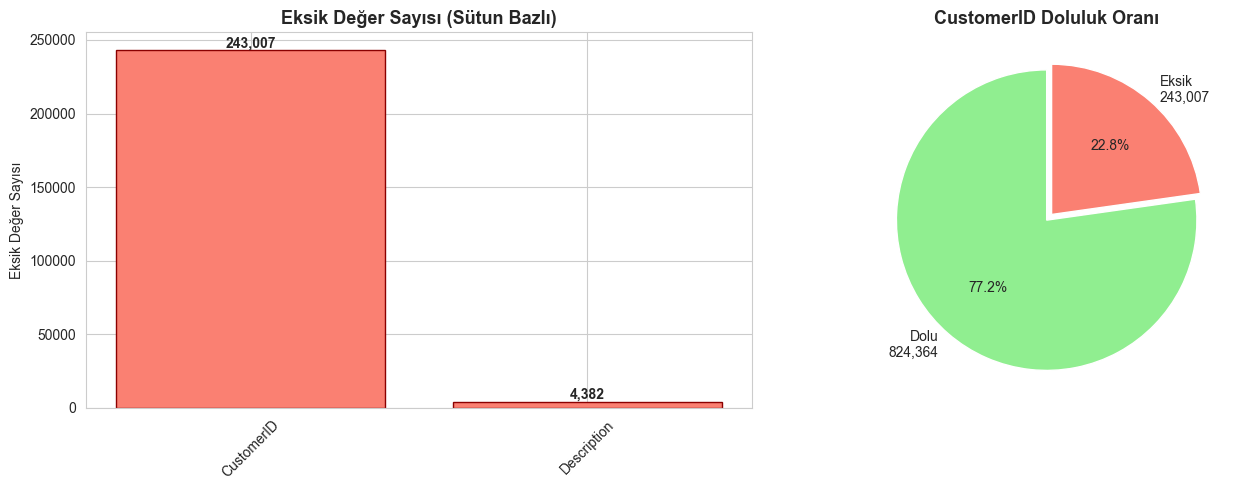

In [9]:
# Eksik değer görselleştirmesi
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar chart
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

ax[0].bar(missing_counts.index, missing_counts.values, color='salmon', edgecolor='darkred')
ax[0].set_title('Eksik Değer Sayısı (Sütun Bazlı)', fontsize=13, fontweight='bold')
ax[0].set_ylabel('Eksik Değer Sayısı')
ax[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(missing_counts.values):
    ax[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# 2. Pasta grafiği - Toplam doluluk
total = len(df)
missing_total = df['CustomerID'].isnull().sum()
present_total = total - missing_total

ax[1].pie([present_total, missing_total],
         labels=[f'Dolu\n{present_total:,}', f'Eksik\n{missing_total:,}'],
         colors=['lightgreen', 'salmon'],
         autopct='%1.1f%%',
         startangle=90,
         explode=(0, 0.05))
ax[1].set_title('CustomerID Doluluk Oranı', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. İptal Edilmiş İşlemler

PDF'teki notlara göre: **InvoiceNo "C" ile başlıyorsa, bu işlem iptal edilmiştir.** İptal edilen işlemlerde Quantity negatif olur.

In [10]:
# InvoiceNo'yu string'e çevir (bazıları int olabilir)
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

cancellations = df[df['InvoiceNo'].str.startswith('C')]
normal_invoices = df[~df['InvoiceNo'].str.startswith('C')]

print("=" * 80)
print("İPTAL EDİLMİŞ FATURALAR")
print("=" * 80)
print(f"❌ İptal edilen işlem sayısı: {len(cancellations):,}")
print(f"✅ Normal işlem sayısı:      {len(normal_invoices):,}")
print(f"📉 İptal oranı:               %{len(cancellations) / len(df) * 100:.2f}")

print(f"\n📌 İptal edilen işlemlerde Quantity istatistikleri:")
print(cancellations['Quantity'].describe())

print(f"\n📋 Örnek iptal kayıtları (ilk 3):")
cancellations[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head(3)

İPTAL EDİLMİŞ FATURALAR
❌ İptal edilen işlem sayısı: 19,494
✅ Normal işlem sayısı:      1,047,877
📉 İptal oranı:               %1.83

📌 İptal edilen işlemlerde Quantity istatistikleri:
count    19494.00
mean       -25.19
std        805.10
min     -80995.00
25%         -6.00
50%         -2.00
75%         -1.00
max          1.00
Name: Quantity, dtype: float64

📋 Örnek iptal kayıtları (ilk 3):


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2.95
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,1.65
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,4.25


## 5. Tarih Aralığı

Veri setinin zaman aralığını ve genel zamansal dağılımını inceliyoruz.

In [11]:
# InvoiceDate'i datetime tipine çevir
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("=" * 80)
print("TARİH ARALIĞI")
print("=" * 80)
print(f"📅 En eski işlem: {df['InvoiceDate'].min()}")
print(f"📅 En yeni işlem: {df['InvoiceDate'].max()}")

date_diff = df['InvoiceDate'].max() - df['InvoiceDate'].min()
print(f"⏱️  Toplam zaman aralığı: {date_diff.days} gün ({date_diff.days // 30} ay)")

# Yıl ve ay dağılımı
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

print(f"\n📊 Yıllara göre işlem sayısı:")
print(df['Year'].value_counts().sort_index())

TARİH ARALIĞI
📅 En eski işlem: 2009-12-01 07:45:00
📅 En yeni işlem: 2011-12-09 12:50:00
⏱️  Toplam zaman aralığı: 738 gün (24 ay)

📊 Yıllara göre işlem sayısı:
Year
2009     45228
2010    522714
2011    499429
Name: count, dtype: int64


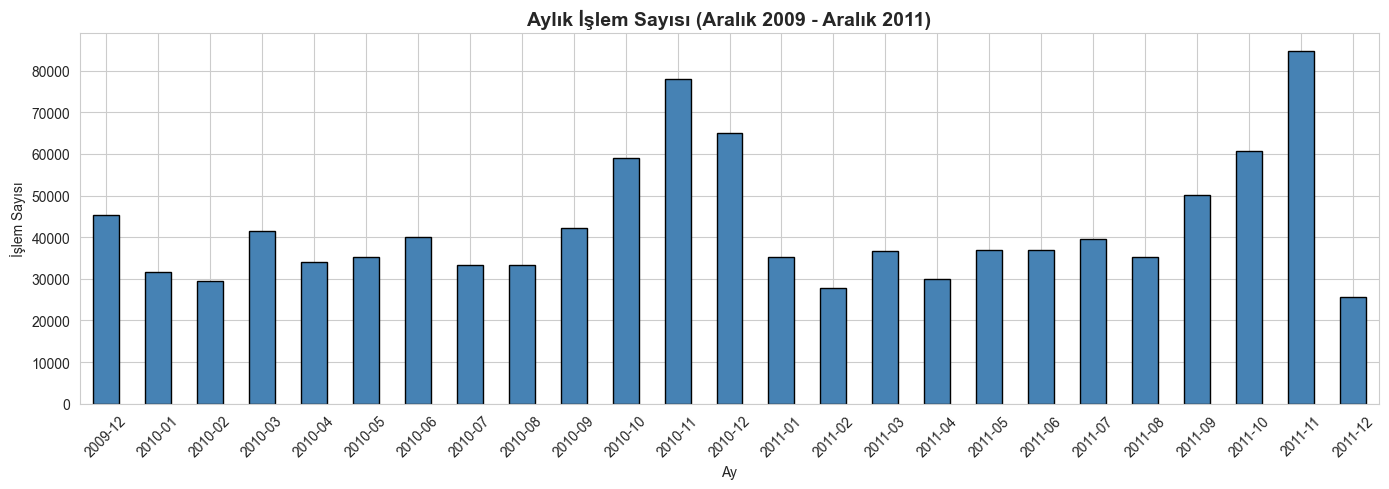

In [12]:
# Aylık işlem sayısı
monthly_counts = df.groupby('YearMonth').size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Aylık İşlem Sayısı (Aralık 2009 - Aralık 2011)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ay')
ax.set_ylabel('İşlem Sayısı')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Ülke Dağılımı

Şirket UK merkezli, müşterileri çoğunlukla UK'da. Diğer ülke dağılımına bakalım.

In [13]:
country_dist = df['Country'].value_counts()

print("=" * 80)
print("ÜLKE DAĞILIMI - TOP 10")
print("=" * 80)
print(country_dist.head(10))

print(f"\n🌍 Toplam ülke sayısı: {df['Country'].nunique()}")
print(f"🇬🇧 UK'nin payı: %{country_dist['United Kingdom'] / len(df) * 100:.2f}")

ÜLKE DAĞILIMI - TOP 10
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

🌍 Toplam ülke sayısı: 43
🇬🇧 UK'nin payı: %91.94


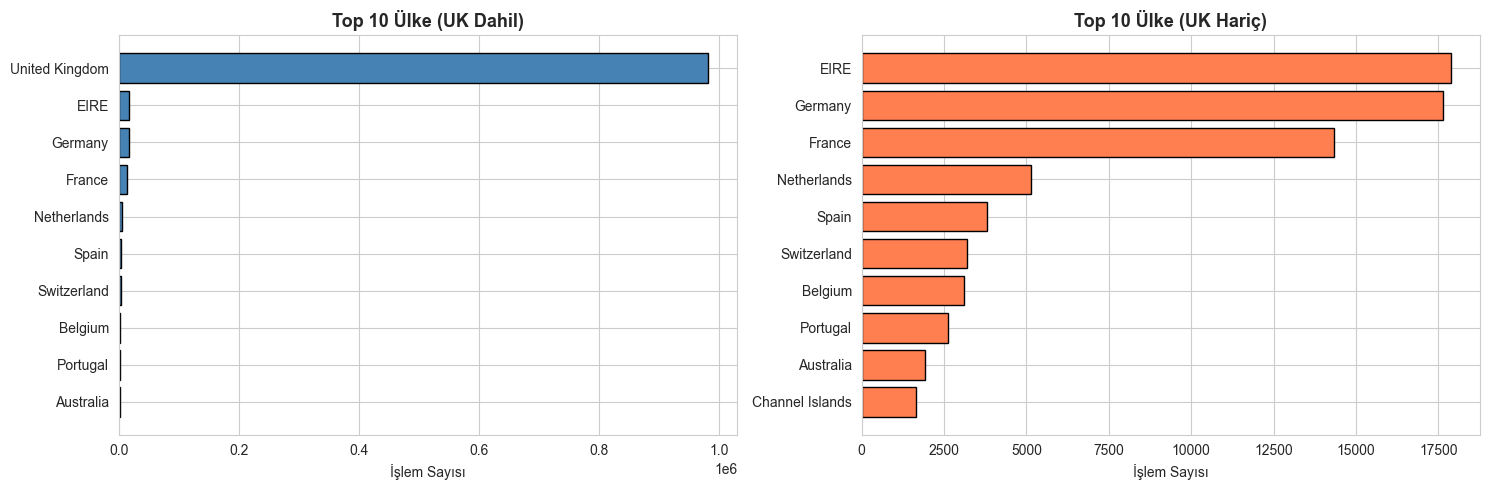

In [14]:
# Top 10 ülke - UK hariç ve dahil
top10 = country_dist.head(10)
top10_no_uk = country_dist[country_dist.index != 'United Kingdom'].head(10)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Top 10 - UK Dahil
ax[0].barh(top10.index[::-1], top10.values[::-1], color='steelblue', edgecolor='black')
ax[0].set_title('Top 10 Ülke (UK Dahil)', fontsize=13, fontweight='bold')
ax[0].set_xlabel('İşlem Sayısı')

# Top 10 - UK Hariç
ax[1].barh(top10_no_uk.index[::-1], top10_no_uk.values[::-1], color='coral', edgecolor='black')
ax[1].set_title('Top 10 Ülke (UK Hariç)', fontsize=13, fontweight='bold')
ax[1].set_xlabel('İşlem Sayısı')

plt.tight_layout()
plt.show()

## 7. Müşteri ve Ürün İstatistikleri

Kaç müşteri, kaç ürün, kaç fatura var?

In [15]:
print("=" * 80)
print("MÜŞTERİ VE ÜRÜN İSTATİSTİKLERİ")
print("=" * 80)
print(f"👤 Benzersiz müşteri sayısı: {df['CustomerID'].nunique():,}")
print(f"📦 Benzersiz ürün sayısı:    {df['StockCode'].nunique():,}")
print(f"🧾 Benzersiz fatura sayısı:   {df['InvoiceNo'].nunique():,}")

# CustomerID null olmayanlar üzerinden
df_valid = df.dropna(subset=['CustomerID'])
print(f"\n📊 CustomerID dolu olan satır sayısı:           {len(df_valid):,}")
print(f"📊 CustomerID dolu olanlardaki benzersiz müşteri: {df_valid['CustomerID'].nunique():,}")

# Müşteri başına ortalama fatura
customer_invoice_count = df_valid.groupby('CustomerID')['InvoiceNo'].nunique()
print(f"\n📈 Müşteri başına ortalama fatura: {customer_invoice_count.mean():.2f}")
print(f"📈 Müşteri başına median fatura:   {customer_invoice_count.median():.2f}")
print(f"📈 En çok alışveriş yapan müşteri: {customer_invoice_count.max()} fatura")

MÜŞTERİ VE ÜRÜN İSTATİSTİKLERİ
👤 Benzersiz müşteri sayısı: 5,942
📦 Benzersiz ürün sayısı:    5,305
🧾 Benzersiz fatura sayısı:   53,628

📊 CustomerID dolu olan satır sayısı:           824,364
📊 CustomerID dolu olanlardaki benzersiz müşteri: 5,942

📈 Müşteri başına ortalama fatura: 7.55
📈 Müşteri başına median fatura:   4.00
📈 En çok alışveriş yapan müşteri: 510 fatura


## 8. Anormal Değerler

Negatif veya sıfır olan Quantity ve UnitPrice değerleri.

In [16]:
print("=" * 80)
print("ANORMAL DEĞERLER")
print("=" * 80)
print(f"📉 Quantity ≤ 0 olan satır:  {(df['Quantity'] <= 0).sum():,}")
print(f"📉 Quantity = 0 olan satır:  {(df['Quantity'] == 0).sum():,}")
print(f"📉 Quantity < 0 olan satır:  {(df['Quantity'] < 0).sum():,}")
print(f"📉 UnitPrice ≤ 0 olan satır: {(df['UnitPrice'] <= 0).sum():,}")
print(f"📉 UnitPrice = 0 olan satır: {(df['UnitPrice'] == 0).sum():,}")
print(f"📉 UnitPrice < 0 olan satır: {(df['UnitPrice'] < 0).sum():,}")

# StockCode'da harf içeren özel kodlar (POSTAGE, AMAZONFEE vb.)
df['StockCode'] = df['StockCode'].astype(str)
non_product_codes = df[df['StockCode'].str.contains('[A-Za-z]', regex=True, na=False)]
print(f"\n🔍 StockCode'da harf içeren satır: {len(non_product_codes):,}")
print(f"   ↳ Örnek özel kodlar: {non_product_codes['StockCode'].unique()[:10]}")

ANORMAL DEĞERLER
📉 Quantity ≤ 0 olan satır:  22,950
📉 Quantity = 0 olan satır:  0
📉 Quantity < 0 olan satır:  22,950
📉 UnitPrice ≤ 0 olan satır: 6,207
📉 UnitPrice = 0 olan satır: 6,202
📉 UnitPrice < 0 olan satır: 5

🔍 StockCode'da harf içeren satır: 134,986
   ↳ Örnek özel kodlar: ['79323P' '79323W' '48173C' '35004B' '84596F' '84596L' '84507B' '84970S'
 '84031A' '84031B']


## 9. Bulgular ve Sonraki Adımlar

### 🔍 Önemli Bulgular

| Bulgu | Detay | Aksiyon |
|-------|-------|---------|
| CustomerID eksik | ~%20 satır | ML için drop edilecek |
| İptal işlemler | "C" prefixli, ~%2 | Ayrı flag'lenecek |
| Negatif Quantity | İadeler | Ayrı kategori |
| 0/Negatif UnitPrice | Hatalı kayıtlar | Filtrelenecek |
| Özel StockCode | POSTAGE, AMAZONFEE vb. | Üründen ayrılacak |

### 📋 Producer İçin Notlar (Faz 3)
- Tarihe göre sıralanmış veri akışı simüle edilecek
- Her satır JSON Kafka mesajı olacak
- Mesaj formatı:
```json
  {
    "timestamp": "...",
    "kullanici_ID": ...,
    "olay_tipi": "purchase|cancellation",
    "ilgili_ID": "InvoiceNo",
    "stock_code": "...",
    "quantity": ...,
    "unit_price": ...,
    "country": "..."
  }
```

### 📋 Spark/Delta Lake İçin Notlar (Faz 4)
- **Bronze:** Ham JSON, hiç temizleme yok
- **Silver:** CustomerID null'ları drop, anormal değerleri filtrele, total_price ekle
- **Gold:** Müşteri seviyesinde agregasyon (feature engineering)

### 📋 Feature Engineering İçin Notlar (Faz 6)
- **Veriyi 2 döneme böleceğiz:**
  - **Geçmiş dönem (feature dönemi):** ~ilk 18 ay
  - **Tahmin dönemi (target dönemi):** ~son 6 ay
- **Hedef:** Müşterinin tahmin döneminde yapacağı toplam harcama (regresyon)
- **Türetilebilecek özellikler (RFM + ek):**
  1. **Recency:** Son alışverişten gözlem tarihine gün
  2. **Frequency:** Toplam fatura sayısı
  3. **Monetary:** Toplam harcama
  4. **Avg_Basket_Value:** Ortalama sepet tutarı
  5. **Avg_Days_Between_Purchases:** Alışverişler arası gün
  6. **Unique_Products:** Kaç farklı ürün
  7. **Country_OneHot:** Ülke (one-hot)
  8. **Cancellation_Rate:** İptal oranı
  9. **Active_Months:** Kaç farklı ayda alışveriş
  10. **Most_Active_Hour:** En çok hangi saatte